### Imports

In [194]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Read Dataset

In [69]:
df = pd.read_csv('housing.csv')

print(df.shape) # 545 rows, with 13 columns each

(545, 13)


In [18]:
df.head() # Some examples of the data

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [19]:
df.describe() # Some statistics of the data

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


### Remove duplicates or null values

In [ ]:
df.duplicated().sum() # No duplicates so there is no need to remove them

np.int64(0)

In [ ]:
df.isnull().sum() # No null values so there is no need to replace them

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

### Exploratory Data Analysis

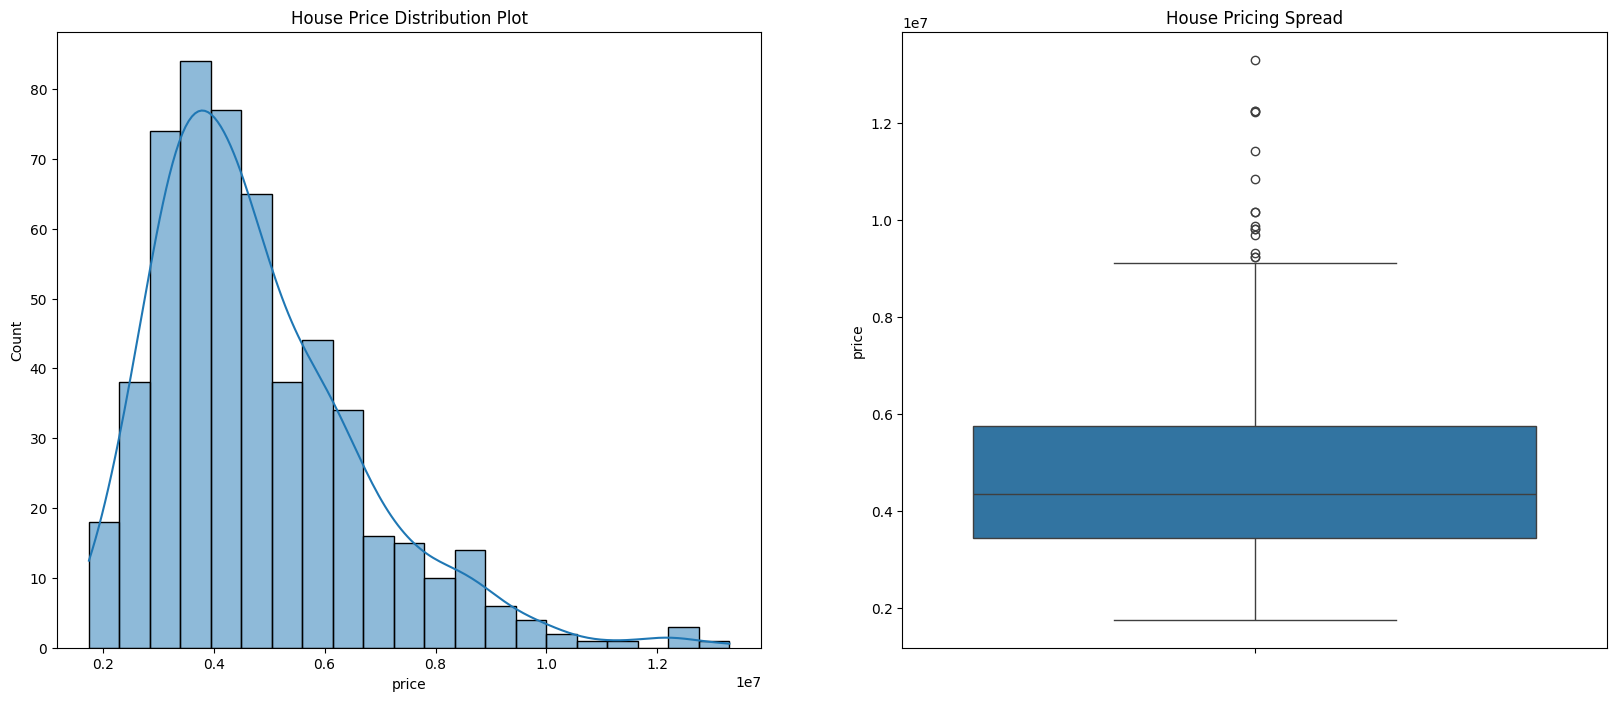

In [37]:
plt.figure(figsize=(20,8))

plt.subplot(1,2,1)
plt.title('House Price Distribution Plot')
sns.histplot(df.price, kde=True)

plt.subplot(1,2,2)
sns.boxplot(df.price)
plt.title('House Pricing Spread')

plt.show()

In [38]:
print(df.price.describe(percentiles = [0.25,0.50,0.75,0.85,0.90,1]))

count    5.450000e+02
mean     4.766729e+06
std      1.870440e+06
min      1.750000e+06
25%      3.430000e+06
50%      4.340000e+06
75%      5.740000e+06
85%      6.615000e+06
90%      7.350000e+06
100%     1.330000e+07
max      1.330000e+07
Name: price, dtype: float64


### Visualising Categorical Data

In [44]:
categorical_list = [x for x in df.columns if df[x].dtype == 'object']
for x in categorical_list:
    print(f"{x}: {df[x].unique()}")

mainroad: ['yes' 'no']
guestroom: ['no' 'yes']
basement: ['no' 'yes']
hotwaterheating: ['no' 'yes']
airconditioning: ['yes' 'no']
prefarea: ['yes' 'no']
furnishingstatus: ['furnished' 'semi-furnished' 'unfurnished']


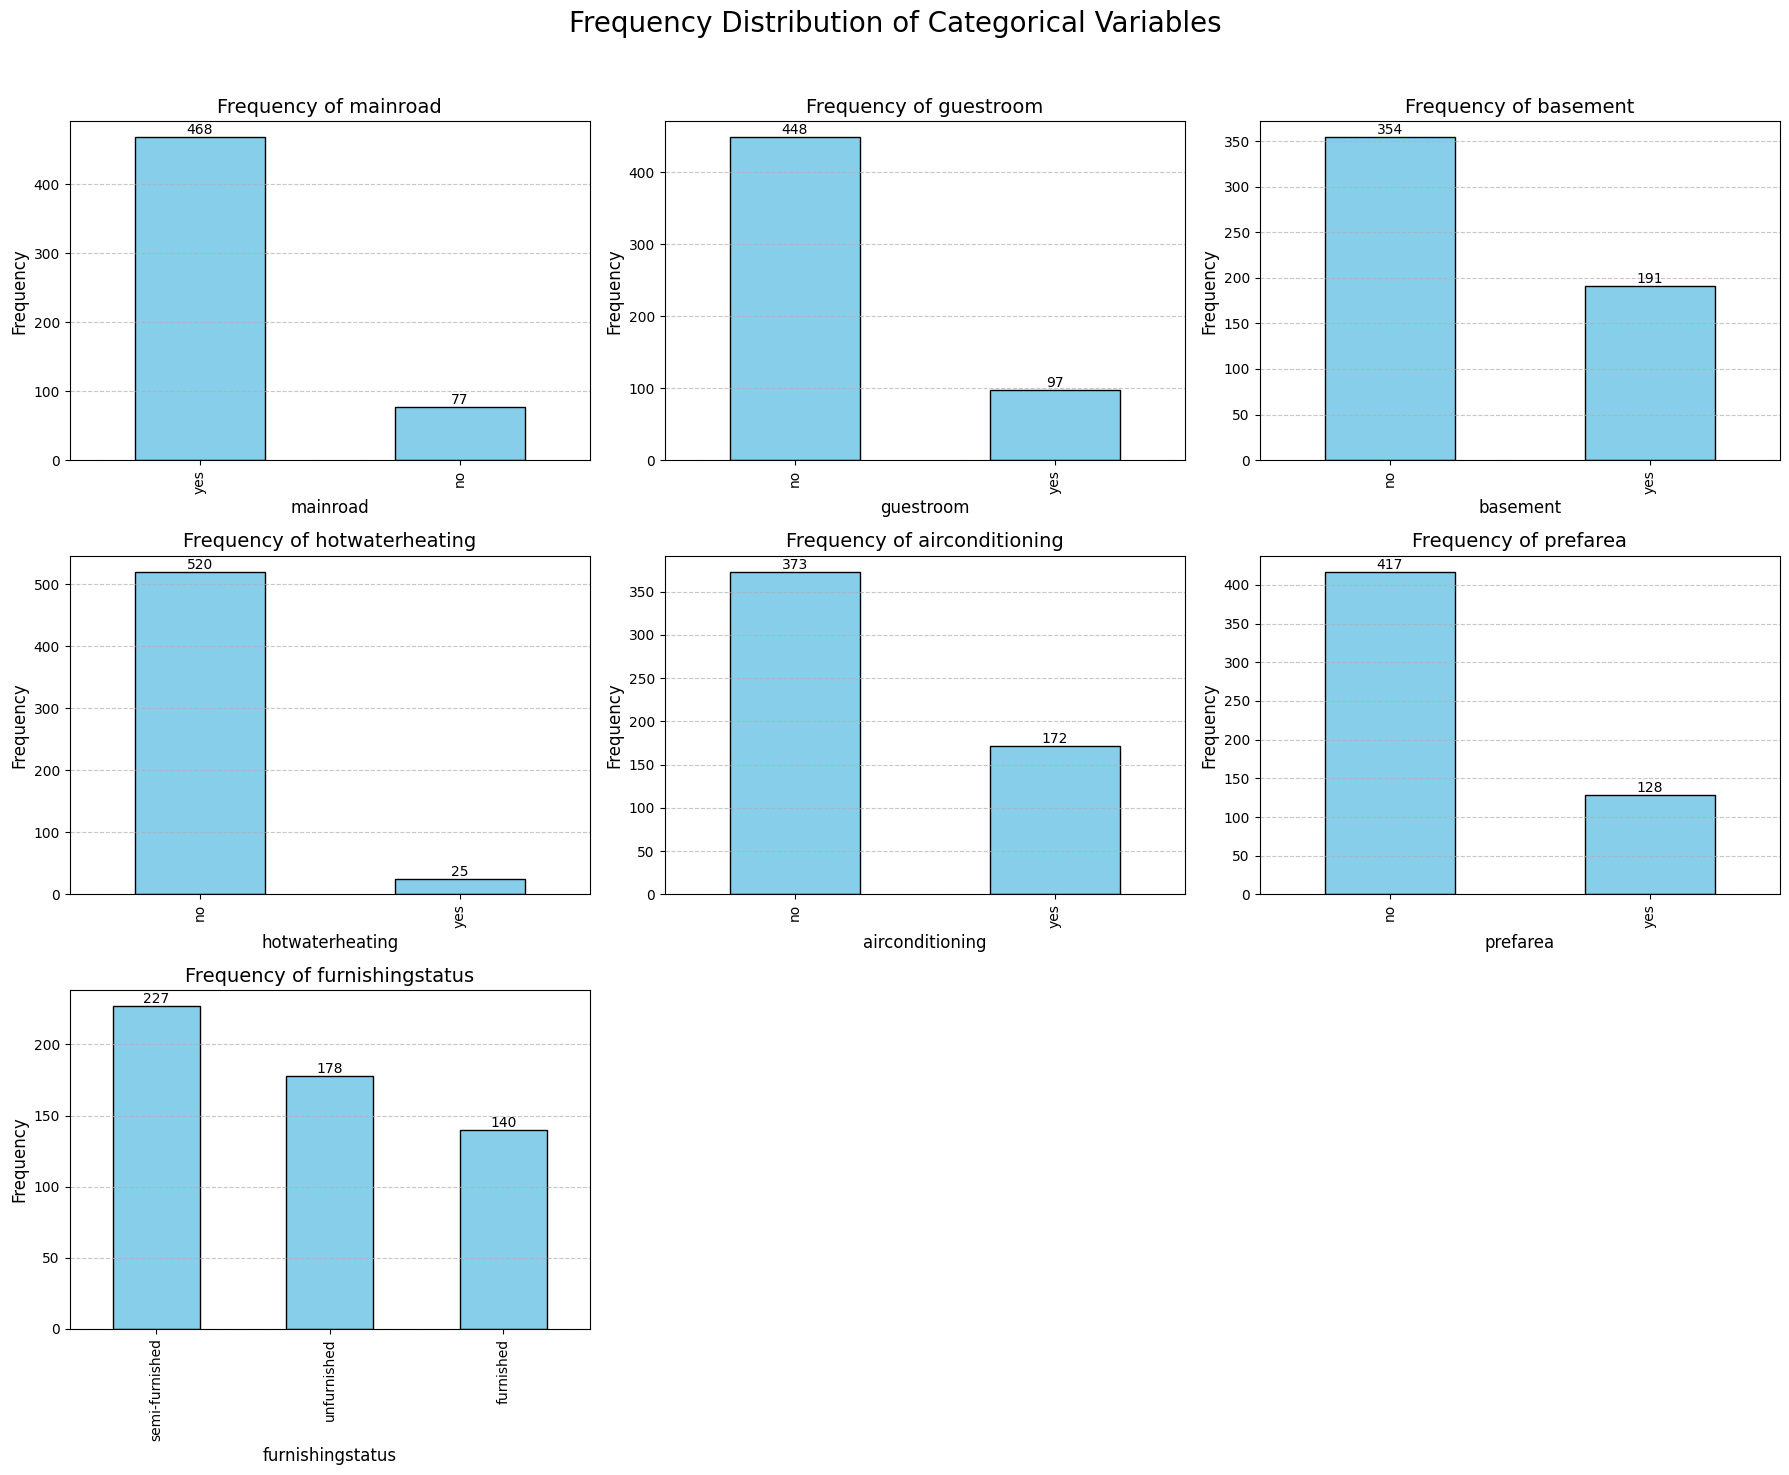

In [43]:
# Plot all categorical variables together for easier comparison and readability

num_cats = len(categorical_list)
cols = 3
rows = (num_cats // cols) + (num_cats % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
fig.suptitle("Frequency Distribution of Categorical Variables", fontsize=20)

for idx, col in enumerate(categorical_list):
    ax = axes[idx // cols, idx % cols] if rows > 1 else axes[idx % cols]
    value_counts = df[col].value_counts()
    value_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='k')
    ax.set_title(f"Frequency of {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=10, color='black')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
# Hide any unused subplots
for empty in range(idx + 1, rows * cols):
    fig.delaxes(axes.flatten()[empty])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

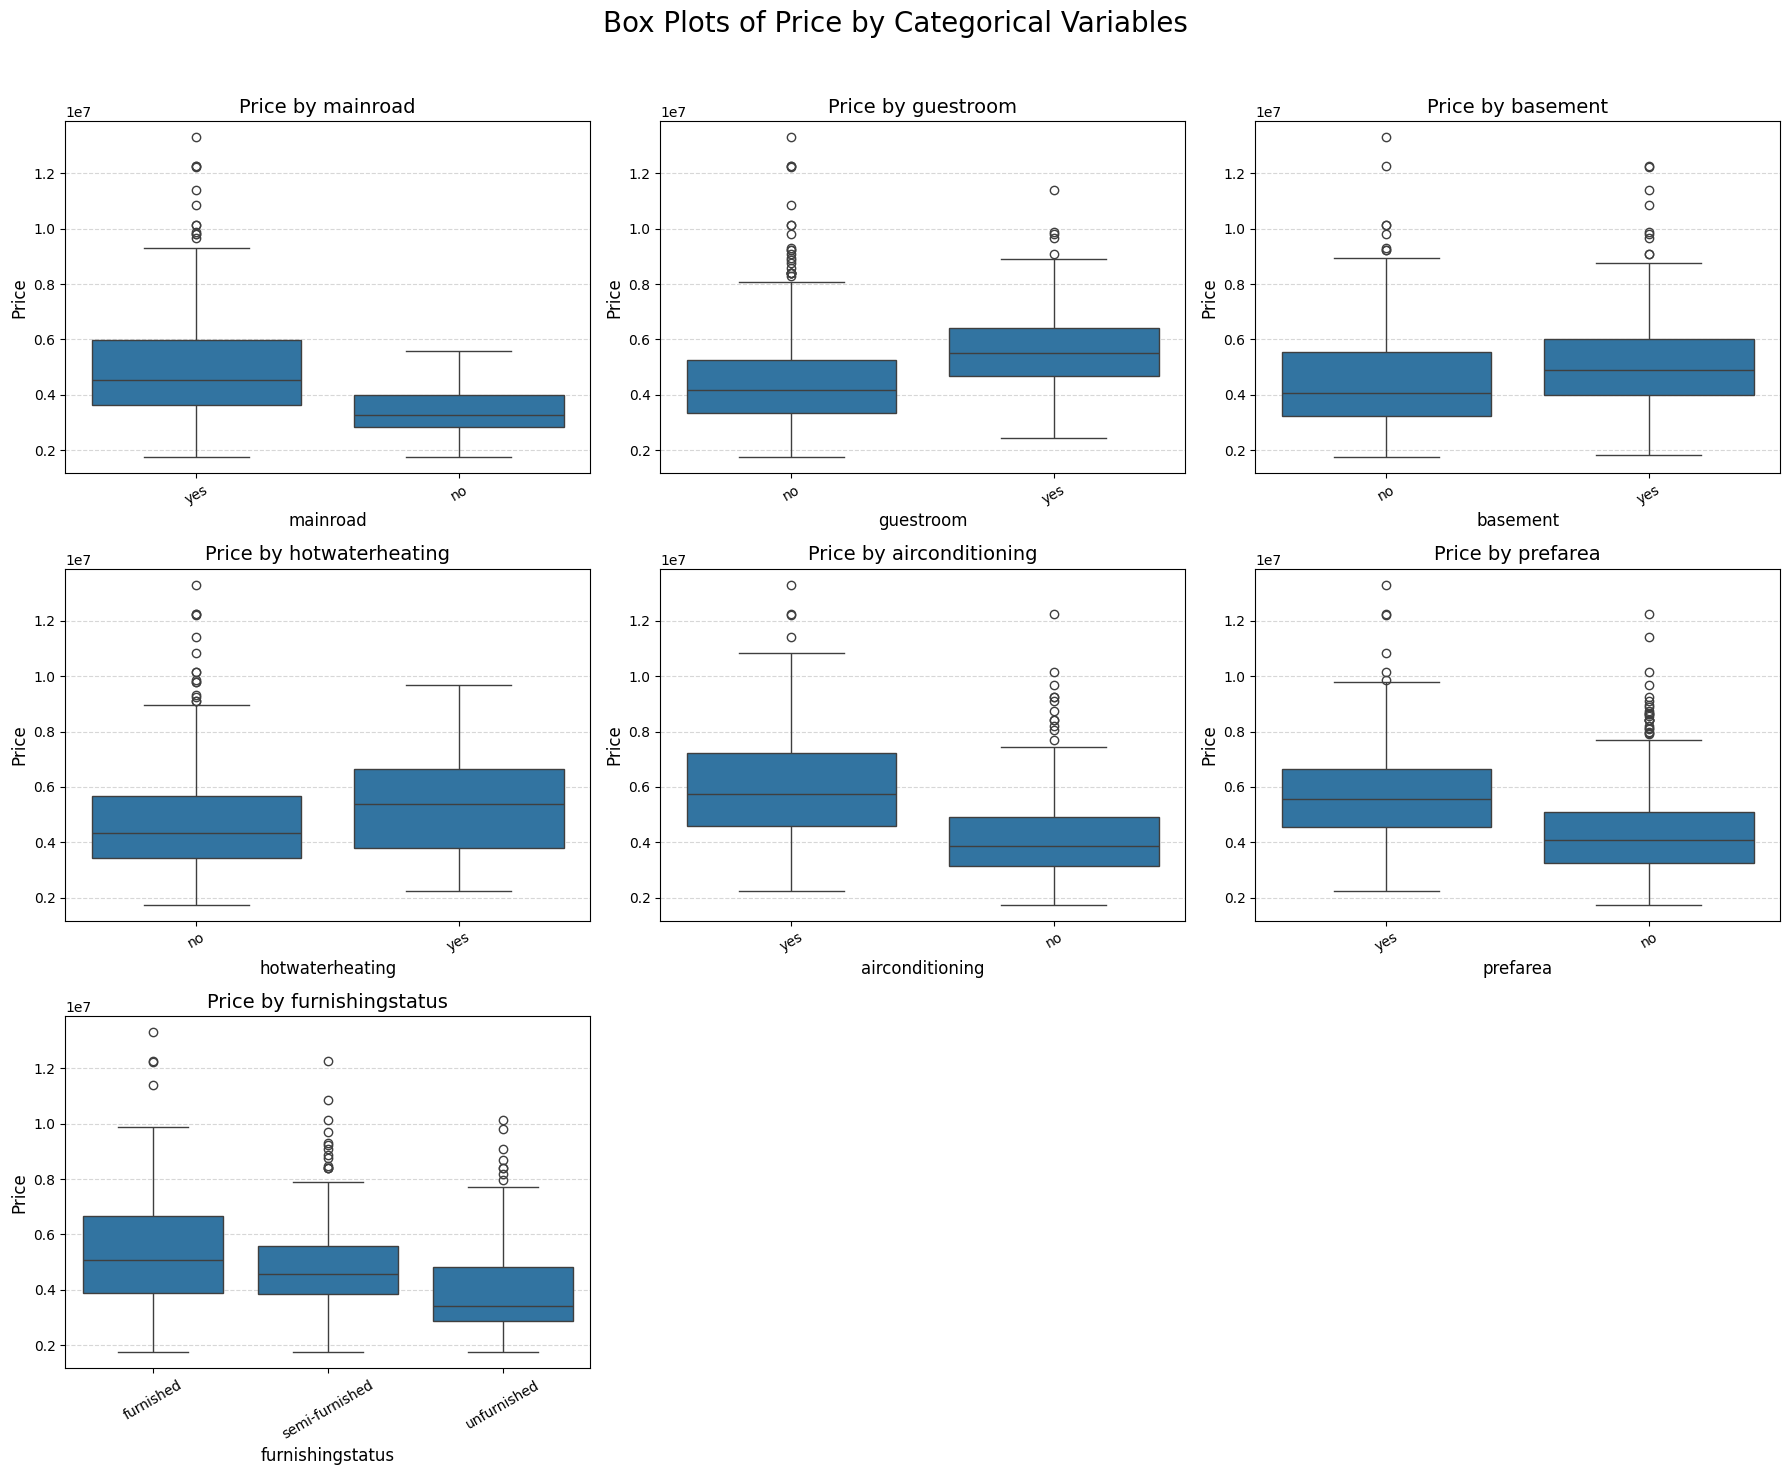

In [46]:
# Plot boxplots of price by each categorical variable in a grid of subplots

num_cats = len(categorical_list)
cols = 3
rows = (num_cats // cols) + (num_cats % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
fig.suptitle("Box Plots of Price by Categorical Variables", fontsize=20)

for idx, col in enumerate(categorical_list):
    ax = axes[idx // cols, idx % cols] if rows > 1 else axes[idx % cols]
    sns.boxplot(data=df, x=col, y='price', ax=ax)
    ax.set_title(f"Price by {col}", fontsize=14)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel("Price", fontsize=12)
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

# Hide any unused subplots
for empty in range(idx + 1, rows * cols):
    fig.delaxes(axes.flatten()[empty])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Visualising numerical data

In [47]:
numerical_list = [x for x in df.columns if df[x].dtype in ('int64','float64')]
print(numerical_list)

['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']


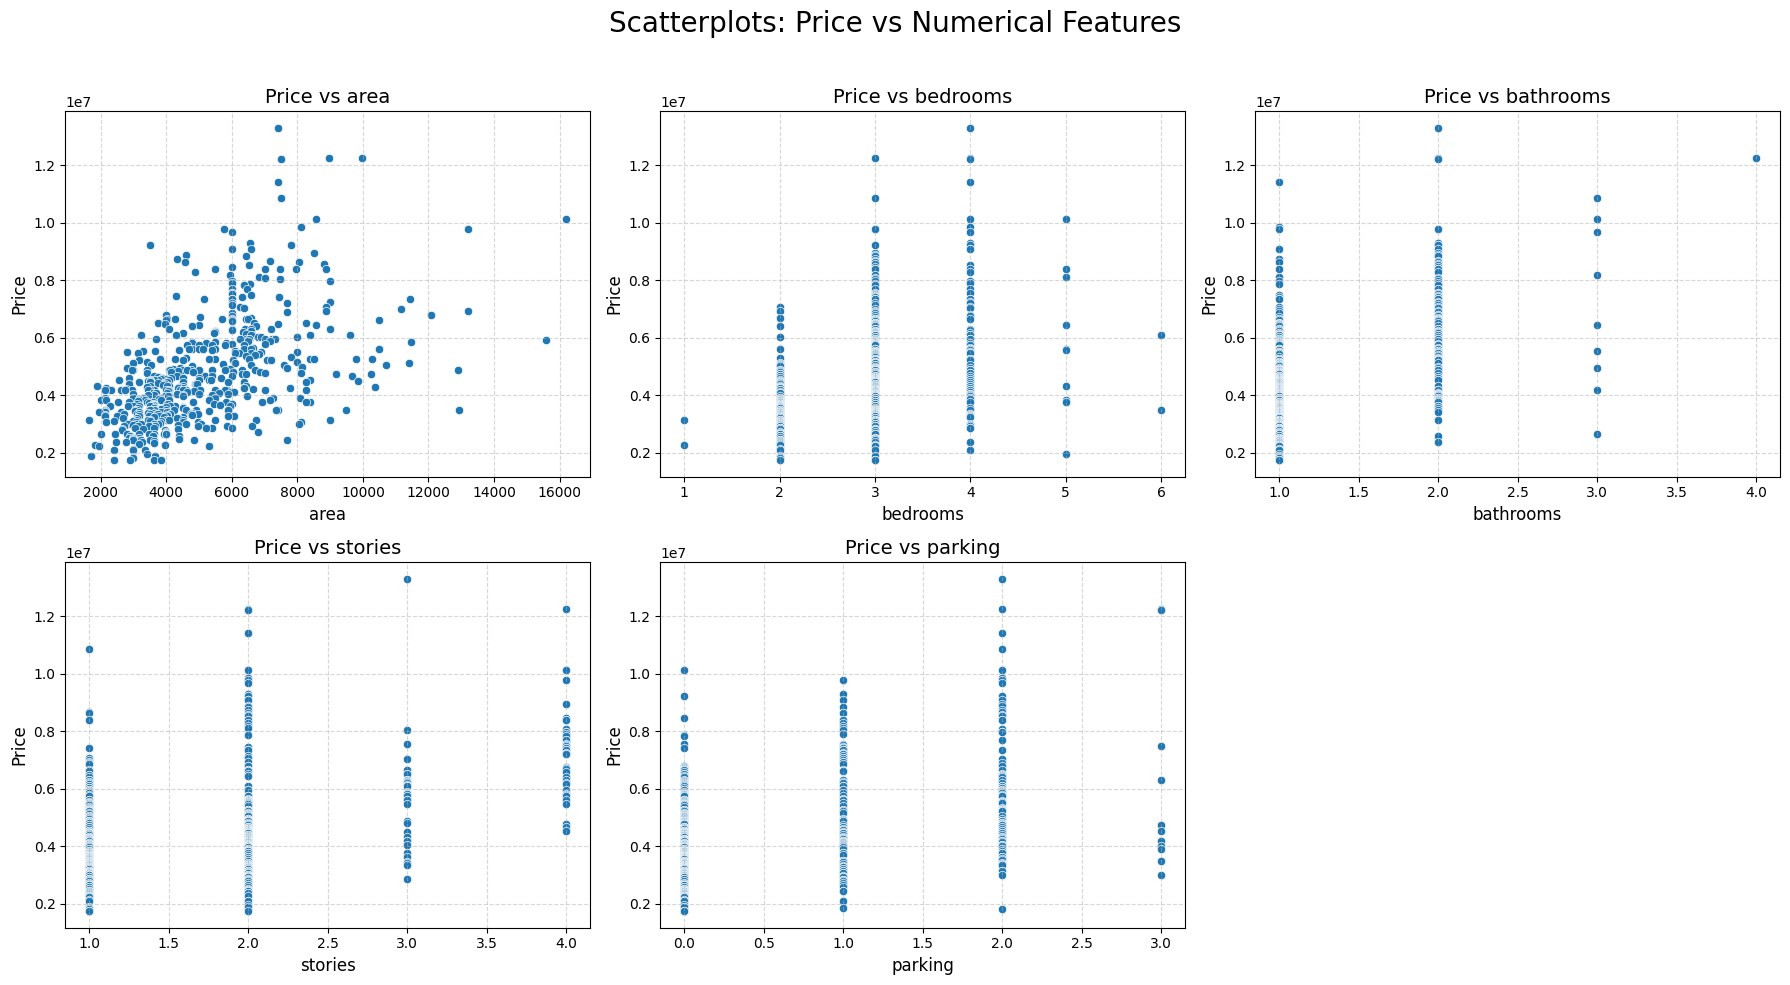

In [48]:
num_features = [col for col in numerical_list if col != 'price']

cols = 3
rows = (len(num_features) // cols) + (len(num_features) % cols > 0)
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
fig.suptitle("Scatterplots: Price vs Numerical Features", fontsize=20)

for idx, col in enumerate(num_features):
    ax = axes[idx // cols, idx % cols] if rows > 1 else axes[idx % cols]
    sns.scatterplot(x=df[col], y=df['price'], ax=ax)
    ax.set_xlabel(col, fontsize=12)
    ax.set_ylabel('Price', fontsize=12)
    ax.set_title(f"Price vs {col}", fontsize=14)
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots
for empty in range(idx + 1, rows * cols):
    fig.delaxes(axes.flatten()[empty])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


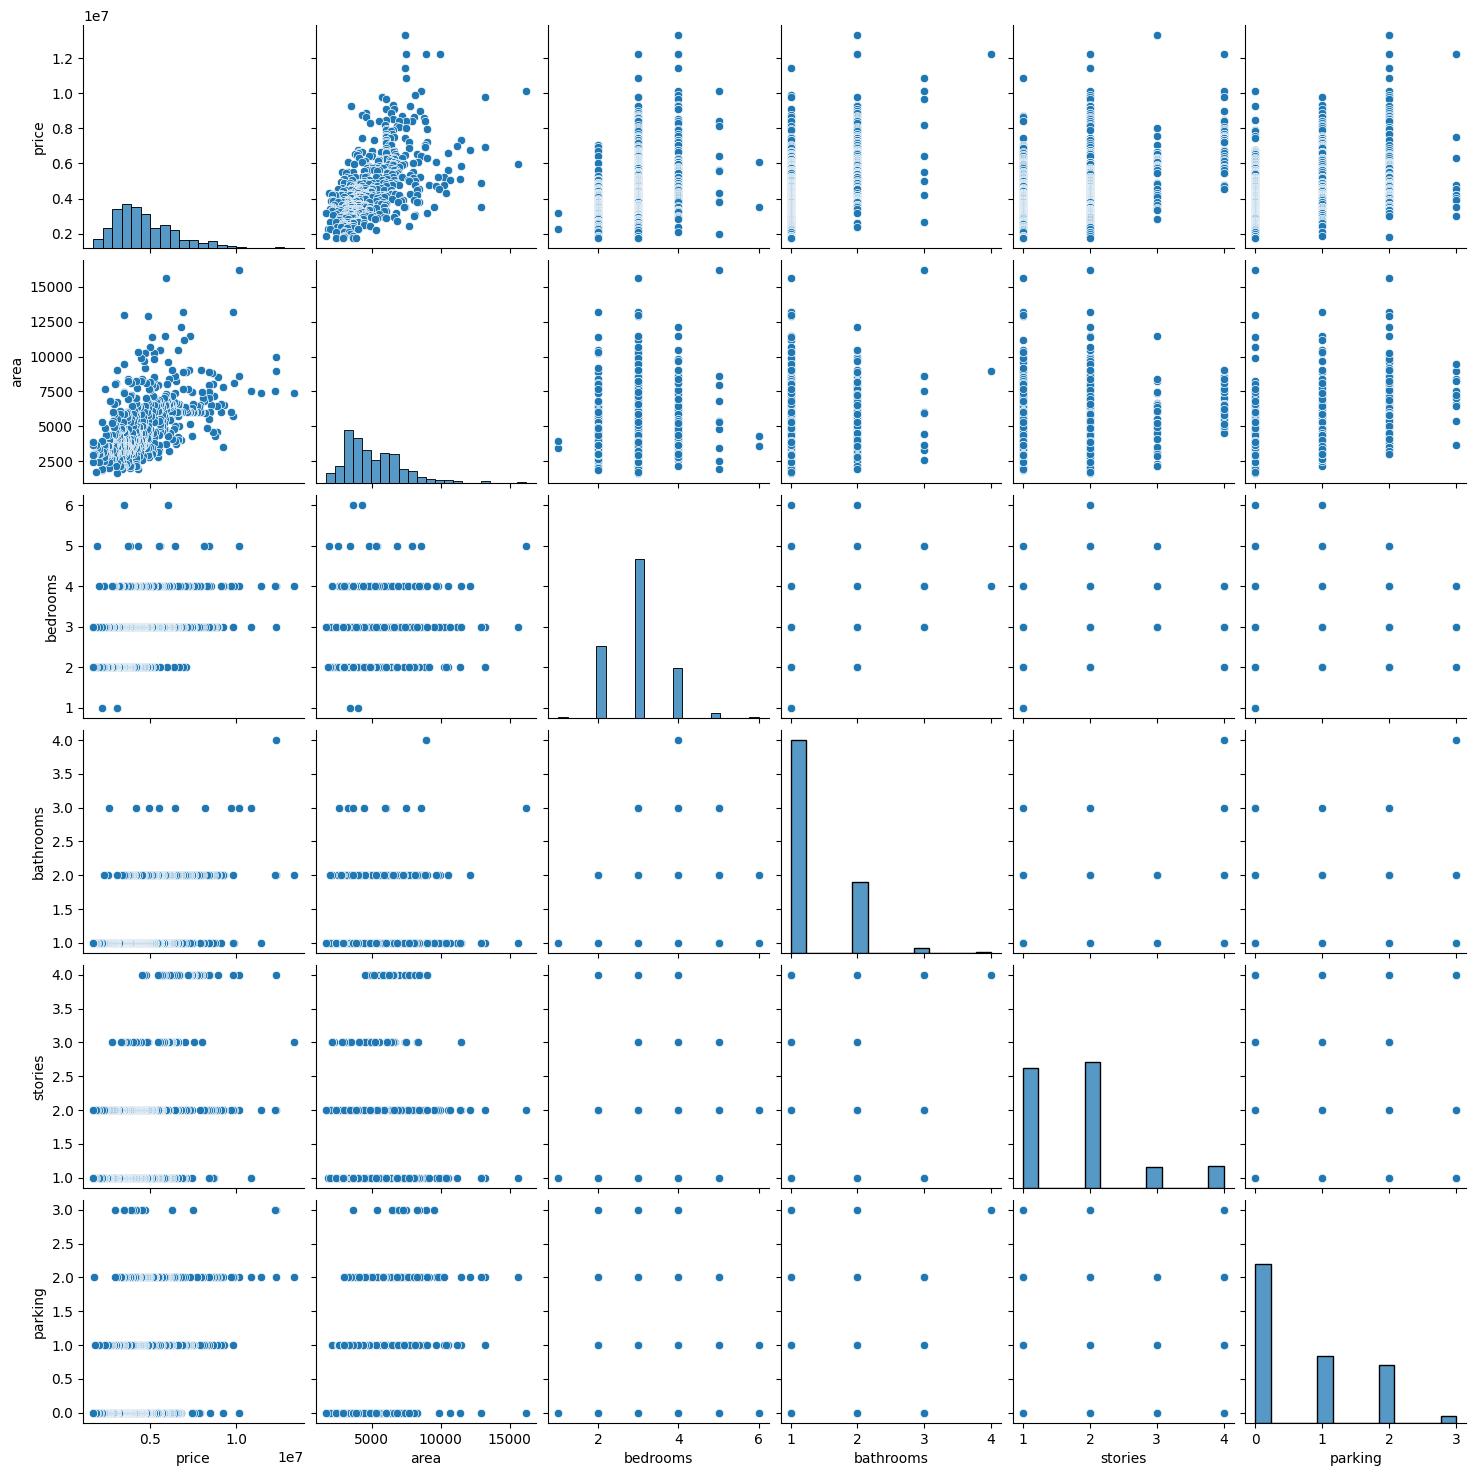

In [49]:
sns.pairplot(df)
plt.show()

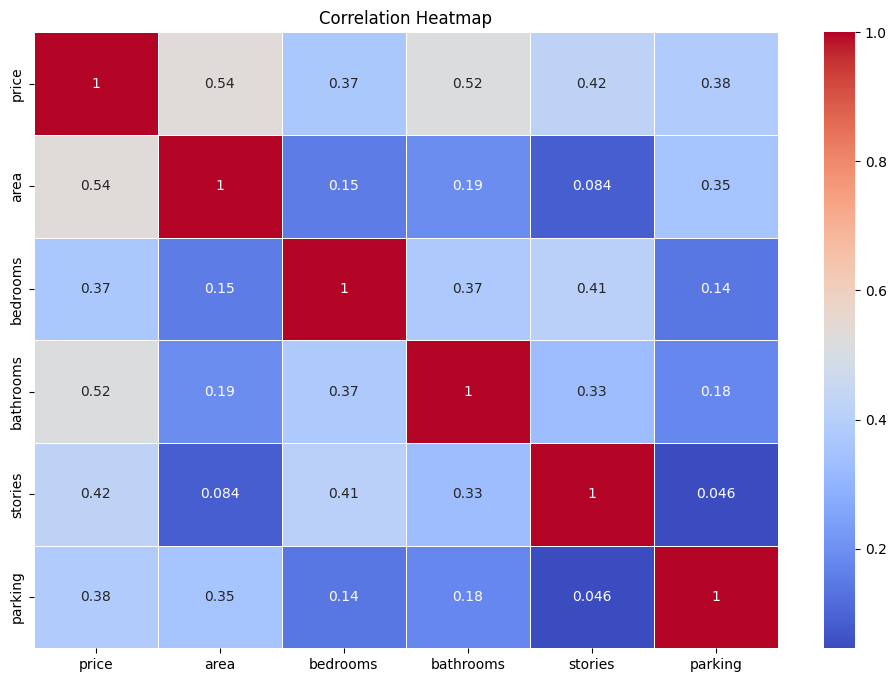

In [52]:
cor_matrix= df[numerical_list].corr()
plt.figure(figsize=(12, 8))  # Set the figure size
sns.heatmap(cor_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Transforming categorial variables to dummy_numbers (yes/no)

In [70]:
# Defining the map function, keeping yes/no suffixes in dummy column names
def dummies(x, df):
    temp = pd.get_dummies(df[x], prefix=x, drop_first=True).astype(int)
    df = pd.concat([df, temp], axis=1)
    df.drop([x], axis=1, inplace=True)
    return df

df = dummies('mainroad', df)
df = dummies('guestroom', df)
df = dummies('hotwaterheating', df)
df = dummies('basement', df)
df = dummies('airconditioning', df)
df = dummies('prefarea', df)
df = dummies('furnishingstatus', df)

In [72]:
df.tail()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,hotwaterheating_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
540,1820000,3000,2,1,1,2,1,0,0,1,0,0,0,1
541,1767150,2400,3,1,1,0,0,0,0,0,0,0,1,0
542,1750000,3620,2,1,1,0,1,0,0,0,0,0,0,1
543,1750000,2910,3,1,1,0,0,0,0,0,0,0,0,0
544,1750000,3850,3,1,2,0,1,0,0,0,0,0,0,1


In [74]:
df.shape # Added one column for each categorical variable and dropped the original categorical column. Two columns added for the furnishingstatus variable.

(545, 14)

### Selecting the features

In [142]:
np.random.seed(42)
df_train, df_test = train_test_split(df, train_size = 0.75, test_size = 0.25, random_state = 42)

In [135]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,hotwaterheating_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
167,5285000,4600,2,2,1,2,1,0,0,0,1,0,1,0
368,3675000,5640,2,1,1,0,0,0,0,0,0,0,1,0
301,4200000,3520,3,1,2,0,1,0,0,0,0,1,1,0
527,2275000,1836,2,1,1,0,0,0,0,1,0,0,1,0
382,3570000,3150,3,1,2,0,1,0,0,1,0,0,0,0


In [143]:
scaler_std = StandardScaler()
df_train[numerical_list] = scaler_std.fit_transform(df_train[numerical_list])

In [144]:
df_train.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,hotwaterheating_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
167,0.302351,-0.249347,-1.259623,1.527759,-0.920571,1.560283,1,0,0,0,1,0,1,0
368,-0.609659,0.222627,-1.259623,-0.556942,-0.920571,-0.823970,0,0,0,0,0,0,1,0
301,-0.312264,-0.739473,0.051413,-0.556942,0.245867,-0.823970,1,0,0,0,0,1,1,0
527,-1.402711,-1.503708,-1.259623,-0.556942,-0.920571,-0.823970,0,0,0,1,0,0,1,0
382,-0.669137,-0.907387,0.051413,-0.556942,0.245867,-0.823970,1,0,0,1,0,0,0,0


In [145]:
#Dividing data into X and y variables
y_train = df_train.pop('price')
X_train = df_train

In [170]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=10)
rfe = rfe.fit(X_train, y_train)

In [171]:
# Display selected features along with their rankings
feature_ranking = list(zip(X_train.columns, rfe.ranking_))
selected_features = [feature for feature, rank in feature_ranking if rank == 1]
print("Selected features (ranking = 1):", selected_features)

print("\nAll feature rankings:")
for feature, rank in feature_ranking:
    selected_str = "(SELECTED)" if rank == 1 else ""
    print(f"{feature}: ranking = {rank} {selected_str}")

Selected features (ranking = 1): ['area', 'bathrooms', 'stories', 'mainroad_yes', 'guestroom_yes', 'hotwaterheating_yes', 'basement_yes', 'airconditioning_yes', 'prefarea_yes', 'furnishingstatus_unfurnished']

All feature rankings:
area: ranking = 1 (SELECTED)
bedrooms: ranking = 4 
bathrooms: ranking = 1 (SELECTED)
stories: ranking = 1 (SELECTED)
parking: ranking = 2 
mainroad_yes: ranking = 1 (SELECTED)
guestroom_yes: ranking = 1 (SELECTED)
hotwaterheating_yes: ranking = 1 (SELECTED)
basement_yes: ranking = 1 (SELECTED)
airconditioning_yes: ranking = 1 (SELECTED)
prefarea_yes: ranking = 1 (SELECTED)
furnishingstatus_semi-furnished: ranking = 3 
furnishingstatus_unfurnished: ranking = 1 (SELECTED)


In [172]:
X_train.columns[rfe.support_] # See which features were selected

Index(['area', 'bathrooms', 'stories', 'mainroad_yes', 'guestroom_yes',
       'hotwaterheating_yes', 'basement_yes', 'airconditioning_yes',
       'prefarea_yes', 'furnishingstatus_unfurnished'],
      dtype='object')

In [173]:
X_train_rfe = X_train[X_train.columns[rfe.support_]]
X_train_rfe.head()

,area,bathrooms,stories,mainroad_yes,guestroom_yes,hotwaterheating_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_unfurnished
167,-0.249347,1.527759,-0.920571,1,0,0,0,1,0,0
368,0.222627,-0.556942,-0.920571,0,0,0,0,0,0,0
301,-0.739473,-0.556942,0.245867,1,0,0,0,0,1,0
527,-1.503708,-0.556942,-0.920571,0,0,0,1,0,0,0
382,-0.907387,-0.556942,0.245867,1,0,0,1,0,0,0


### Training the model

In [174]:
def build_model(X,y):
    X = sm.add_constant(X) #Adding the constant for intercept
    lm = sm.OLS(y,X).fit() # fitting the model
    print(lm.summary()) # model summary
    return X
    
def checkVIF(X):
    vif = pd.DataFrame()
    vif['Features'] = X.columns
    vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by = "VIF", ascending = False)
    return(vif)

### First model (not considering VIF)

In [178]:
X_train_new = build_model(X_train_rfe, y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.668
Model:                            OLS   Adj. R-squared:                  0.660
Method:                 Least Squares   F-statistic:                     80.01
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           9.67e-89
Time:                        14:37:27   Log-Likelihood:                -353.76
No. Observations:                 408   AIC:                             729.5
Df Residuals:                     397   BIC:                             773.6
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

### Dropping guestrooms because it is not that important (the P-value is really high)

In [180]:
X_train_new = X_train_new.drop(["guestroom_yes"], axis = 1)
X_train_new = build_model(X_train_new,y_train)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.666
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     88.36
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           3.11e-89
Time:                        14:37:32   Log-Likelihood:                -354.94
No. Observations:                 408   AIC:                             729.9
Df Residuals:                     398   BIC:                             770.0
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

In [181]:
checkVIF(X_train_new)

,Features,VIF
0,const,9.88
3,stories,1.33
7,airconditioning_yes,1.24
1,area,1.20
2,bathrooms,1.19
6,basement_yes,1.16
4,mainroad_yes,1.15
8,prefarea_yes,1.14
9,furnishingstatus_unfurnished,1.07
5,hotwaterheating_yes,1.03


In [182]:
lm = sm.OLS(y_train,X_train_new).fit()
y_train_price = lm.predict(X_train_new)

Text(0.5, 0, 'Errors')

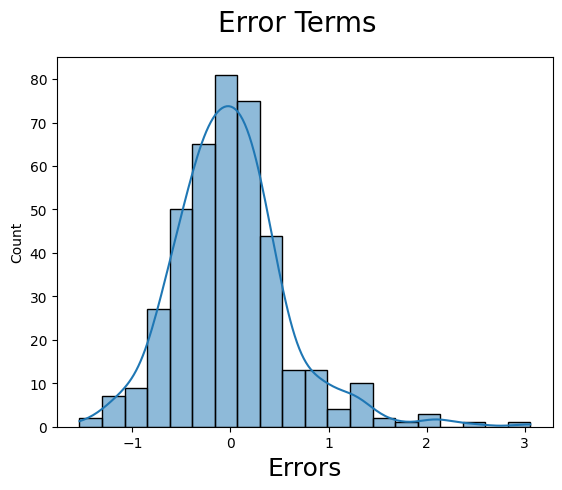

In [183]:
# Plot the histogram of the error terms
fig = plt.figure()
sns.histplot((y_train - y_train_price), bins = 20, kde=True)
fig.suptitle('Error Terms', fontsize = 20)                 
plt.xlabel('Errors', fontsize = 18)   

### Predicting on the test set

In [184]:
df_test[numerical_list] = scaler_std.transform(df_test[numerical_list])

In [185]:
df_test.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,hotwaterheating_yes,basement_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
316,-0.391569,0.340620,1.362450,1.527759,0.245867,0.368157,0,0,0,1,0,0,0,1
77,1.075577,0.612913,0.051413,1.527759,1.412305,-0.823970,1,0,0,0,1,1,0,0
360,-0.589832,-0.503487,-1.259623,-0.556942,-0.920571,-0.823970,1,0,0,0,0,0,1,0
90,0.956619,-0.067818,0.051413,-0.556942,0.245867,-0.823970,1,0,0,0,1,0,1,0
493,-1.105316,-0.539792,0.051413,-0.556942,-0.920571,-0.823970,1,0,0,0,0,0,0,0


In [186]:
y_test = df_test.pop('price')
X_test = df_test

In [189]:
# Get feature names from the FINAL training set (after dropping guestroom_yes)
selected_feature_names = X_train_new.drop('const', axis=1).columns

# Select same features from test set
X_test_new = X_test[selected_feature_names]

# Add constant
X_test_new = sm.add_constant(X_test_new)

In [190]:
y_pred = lm.predict(X_test_new)

In [191]:
r2_score(y_test, y_pred)

0.6478507121053529

Text(0, 0.5, 'y_pred')

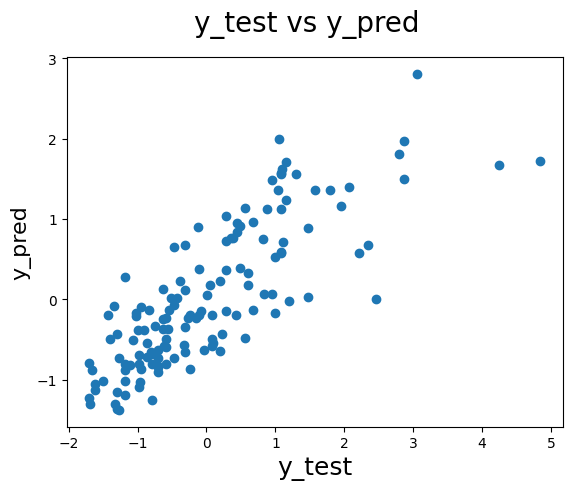

In [192]:
#EVALUATION OF THE MODEL
fig = plt.figure()
plt.scatter(y_test,y_pred)
fig.suptitle('y_test vs y_pred', fontsize=20)              # Plot heading 
plt.xlabel('y_test', fontsize=18)                          # X-label
plt.ylabel('y_pred', fontsize=16)   

In [196]:
# Calculate test metrics
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

# Calculate training metrics for comparison
train_r2 = r2_score(y_train, y_train_price)
train_mae = mean_absolute_error(y_train, y_train_price)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_price))
train_mape = np.mean(np.abs((y_train - y_train_price) / y_train)) * 100

# Create comparison DataFrame
results_df = pd.DataFrame({
    'Metric': ['R² Score', 'MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 'MAPE (%)'],
    'Training': [train_r2, train_mae, train_rmse, train_mape],
    'Test': [test_r2, test_mae, test_rmse, test_mape]
})

results_df['Difference'] = results_df['Test'] - results_df['Training']
results_df = results_df.round(4)

print("=" * 70)
print("MODEL PERFORMANCE EVALUATION")
print("=" * 70)
print("\nTest Set Metrics:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  MAE: {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAPE: {test_mape:.2f}%")
print("\n" + "=" * 70)
print("\nTraining vs Test Comparison:")
print(results_df.to_string(index=False))
print("\n" + "=" * 70)

# Additional statistics
print("\nResidual Statistics (Test Set):")
residuals = y_test - y_pred
print(f"  Mean Residual: {np.mean(residuals):.4f}")
print(f"  Std Residual: {np.std(residuals):.4f}")
print(f"  Min Residual: {np.min(residuals):.4f}")
print(f"  Max Residual: {np.max(residuals):.4f}")

MODEL PERFORMANCE EVALUATION

Test Set Metrics:
  R² Score: 0.6479
  MAE: 0.5266
  RMSE: 0.7216
  MAPE: 139.58%


Training vs Test Comparison:
                        Metric  Training     Test  Difference
                      R² Score    0.6665   0.6479     -0.0186
     MAE (Mean Absolute Error)    0.4221   0.5266      0.1046
RMSE (Root Mean Squared Error)    0.5775   0.7216      0.1441
                      MAPE (%)  233.2419 139.5769    -93.6650


Residual Statistics (Test Set):
  Mean Residual: 0.0032
  Std Residual: 0.7216
  Min Residual: -1.4626
  Max Residual: 3.1265


### Model Results Interpretation

#### Overall Model Performance

**R² Score (Test: 0.6479, Training: 0.6665)**
- The model explains approximately **64.8%** of the variance in house prices on the test set
- This is a **moderate to good** fit for real estate prediction models
- The small difference between training (66.7%) and test (64.8%) R² indicates **good generalization** with minimal overfitting
- A difference of only 1.86% suggests the model is not memorizing training data

**Mean Absolute Error (MAE: 0.5266)**
- On average, predictions are off by **0.5266** units (in standardized scale)
- Since we used StandardScaler, this needs to be interpreted in the context of scaled data
- The test MAE (0.5266) is slightly higher than training MAE (0.4221), which is expected and acceptable
- The 0.10 difference indicates reasonable model stability

**Root Mean Squared Error (RMSE: 0.7216)**
- RMSE penalizes larger errors more than MAE
- Test RMSE (0.7216) is higher than training (0.5775), showing some prediction variance
- The difference of 0.14 suggests the model handles unseen data reasonably well
- RMSE > MAE indicates there are some outliers with larger prediction errors

**Mean Absolute Percentage Error (MAPE: 139.58%)**
- MAPE is high, which is common when dealing with standardized/scaled data
- The high MAPE is likely due to the scaling transformation affecting percentage calculations
- Note: MAPE can be misleading with scaled data; focus more on R², MAE, and RMSE for evaluation

#### Model Generalization Assessment

**Training vs Test Performance:**
- **R² Difference: -0.0186** → Excellent! Very small gap indicates good generalization
- **MAE Difference: +0.1046** → Acceptable increase, model is not overfitting significantly
- **RMSE Difference: +0.1441** → Moderate increase, some larger errors on test set but within acceptable range

**Conclusion:** The model shows **good generalization** with minimal overfitting. The performance on test data is close to training performance, indicating the model learned meaningful patterns rather than memorizing.

#### Residual Analysis

**Mean Residual: 0.0032**
- Very close to zero, indicating **unbiased predictions** (no systematic over/under-prediction)
- This is excellent - the model doesn't consistently overestimate or underestimate prices

**Standard Deviation of Residuals: 0.7216**
- Matches the RMSE (as expected), showing consistent error distribution
- Indicates prediction errors are reasonably distributed around zero

**Residual Range: -1.4626 to 3.1265**
- Some outliers exist (max residual of 3.13 is quite large)
- The negative minimum suggests some houses are significantly over-predicted
- The positive maximum suggests some houses are significantly under-predicted
- These outliers might represent unique properties with unusual characteristics

#### Key Insights

1. **Model Quality:** The model achieves a **decent predictive performance** (R² ≈ 0.65) for house price prediction, which is reasonable for real estate markets where many external factors (location nuances, market timing, etc.) aren't captured in the data.

2. **Feature Importance:** Based on the model coefficients:
   - **Area, bathrooms, and stories** are the strongest predictors (highest coefficients)
   - **Air conditioning and hot water heating** significantly impact price
   - **Basement, mainroad, and preferred area** also contribute meaningfully

3. **Model Limitations:**
   - R² of 0.65 means **35% of price variance remains unexplained**
   - Missing factors might include: exact location coordinates, neighborhood quality, property age, market conditions, etc.
   - The high MAPE (though affected by scaling) suggests some predictions can be quite off

4. **Practical Use:**
   - The model is suitable for **initial price estimates** and understanding key price drivers
   - Should be used alongside domain expertise and local market knowledge
   - Predictions within ±0.72 RMSE units (in scaled space) are expected for most properties

#### Recommendations for Improvement

1. **Feature Engineering:** Consider adding location-based features, property age, nearby amenities
2. **Non-linear Models:** Try polynomial features or tree-based models (Random Forest, XGBoost) to capture non-linear relationships
3. **Outlier Handling:** Investigate properties with large residuals to understand what makes them different
4. **Feature Selection:** Review VIF scores to ensure no multicollinearity issues remain
5. **Cross-Validation:** Implement k-fold cross-validation for more robust performance estimation